<a href="https://colab.research.google.com/github/Svera00/test1/blob/main/Entrega_2__CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción y Objetivos del Proyecto

### ¿De qué va esto?
Este proyecto trata de resolver un problema de visión por computadora usando imágenes de 18 personajes de Los Simpsons. No es tan fácil como el de los números (MNIST) porque aquí los personajes salen en poses raras, con fondos distintos, a veces cortados o con otros personajes al lado. La idea es clasificar imágenes de $64 \times 64$ píxeles.

### Nuestros Objetivos:
*   **General:** Armar y entrenar una red neuronal convolucional (CNN) con TensorFlow para que identifique quién es quién entre 18 categorías.
*   **Específicos:**
    1. Crear un modelo base (baseline) para ver desde dónde partimos.
    2. Probar técnicas de regularización como Dropout y Batch Normalization para que la red no se aprenda las fotos de memoria (overfitting).
    3. Usar Data Augmentation para "inventar" más variedad de fotos y que el modelo sea más pro al final.

## Convolutional Neural Networks

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes de la conocida serie de los Simpsons.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en imágenes de personajes de los Simpsons extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/) y es más complejo que el dataset de Fashion MNIST que hemos utilizado hasta ahora. Aparte de tener más clases (vamos a utilizar los 18 personajes con más imágenes), los personajes pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

El dataset de training puede ser descargado desde aquí:

[Training data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60) (~500MB)

Por otro lado, el dataset de test puede ser descargado de aquí:

[Test data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8) (~10MB)

Antes de empezar la práctica, se recomienda descargar las imágenes y echarlas un vistazo.


## Carga de los datos

In [ ]:
# IMPORTACIÓN DE LIBRERÍAS
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from google.colab import drive

# Conectar Drive y extraer
drive.mount('/content/drive')
!tar -xzf "/content/drive/MyDrive/simpsons_data/simpsons_train.tar.gz" -C /content/
!tar -xzf "/content/drive/MyDrive/simpsons_data/simpsons_test.tar.gz" -C /content/

# Configuración inicial
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}
IMG_SIZE = 64
num_classes = len(MAP_CHARACTERS)

def load_train_set(dirname):
    X, y = [], []
    for label, character in MAP_CHARACTERS.items():
        folder = os.path.join(dirname, character)
        if not os.path.exists(folder): continue
        for img in os.listdir(folder):
            if img.endswith(".jpg"):
                image = cv2.resize(cv2.imread(os.path.join(folder,img)), (IMG_SIZE,IMG_SIZE))
                X.append(image)
                y.append(label)
    return np.array(X), np.array(y)

def load_test_set(dirname):
    X, y = [], []
    reverse = {v:k for k,v in MAP_CHARACTERS.items()}
    for file in glob.glob(dirname+"/*.*"):
        char_name = "_".join(file.split("/")[-1].split("_")[:-1])
        if char_name in reverse:
            image = cv2.resize(cv2.imread(file), (IMG_SIZE,IMG_SIZE))
            X.append(image)
            y.append(reverse[char_name])
    return np.array(X), np.array(y)

# Carga
X, y = load_train_set("/content/simpsons")
X_test, y_test = load_test_set("/content/simpsons_testset")
X = X.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Partición y One-Hot Encoding
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64

In [ ]:
# VERIFICACIÓN DE CARPETAS Y CARGA DEL DATASET
!ls /content/

X, y = load_train_set("/content/simpsons")
X_test, y_test = load_test_set("/content/simpsons_testset")

print(X.shape)
print(X_test.shape)

drive  sample_data  simpsons  simpsons_testset
(18992, 64, 64, 3)
(890, 64, 64, 3)


In [ ]:
!ls

drive  sample_data  simpsons  simpsons_testset


In [ ]:
MAP_CHARACTERS = {
    0:'abraham_grampa_simpson',
    1:'apu_nahasapeemapetilon',
    2:'bart_simpson',
    3:'charles_montgomery_burns',
    4:'chief_wiggum',
    5:'comic_book_guy',
    6:'edna_krabappel',
    7:'homer_simpson',
    8:'kent_brockman',
    9:'krusty_the_clown',
    10:'lisa_simpson',
    11:'marge_simpson',
    12:'milhouse_van_houten',
    13:'moe_szyslak',
    14:'ned_flanders',
    15:'nelson_muntz',
    16:'principal_skinner',
    17:'sideshow_bob'
}

IMG_SIZE = 64
num_classes = len(MAP_CHARACTERS)

def load_train(dirname):
    X,y=[],[]

    for label,character in MAP_CHARACTERS.items():
        folder=os.path.join(dirname,character)

        for img in os.listdir(folder):
            if img.endswith(".jpg"):
                image=cv2.resize(
                    cv2.imread(os.path.join(folder,img)),
                    (IMG_SIZE,IMG_SIZE)
                )
                X.append(image)
                y.append(label)

    return np.array(X),np.array(y)


def load_test(dirname):
    X,y=[],[]
    reverse={v:k for k,v in MAP_CHARACTERS.items()}

    for file in glob.glob(dirname+"/*.*"):
        char="_".join(file.split("/")[-1].split("_")[:-1])

        if char in reverse:
            image=cv2.resize(cv2.imread(file),(IMG_SIZE,IMG_SIZE))
            X.append(image)
            y.append(reverse[char])

    return np.array(X),np.array(y)

# 3. Preprocesamiento

In [ ]:
X,y=load_train("/content/simpsons")
X_test,y_test=load_test("/content/simpsons_testset")

X=X.astype("float32")/255.0
X_test=X_test.astype("float32")/255.0

X_train,X_val,y_train,y_val=train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

y_train_cat=to_categorical(y_train,num_classes)
y_val_cat=to_categorical(y_val,num_classes)
y_test_cat=to_categorical(y_test,num_classes)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(15193, 64, 64, 3)
(3799, 64, 64, 3)
(890, 64, 64, 3)


# 4. VISUALIZAR DATASET

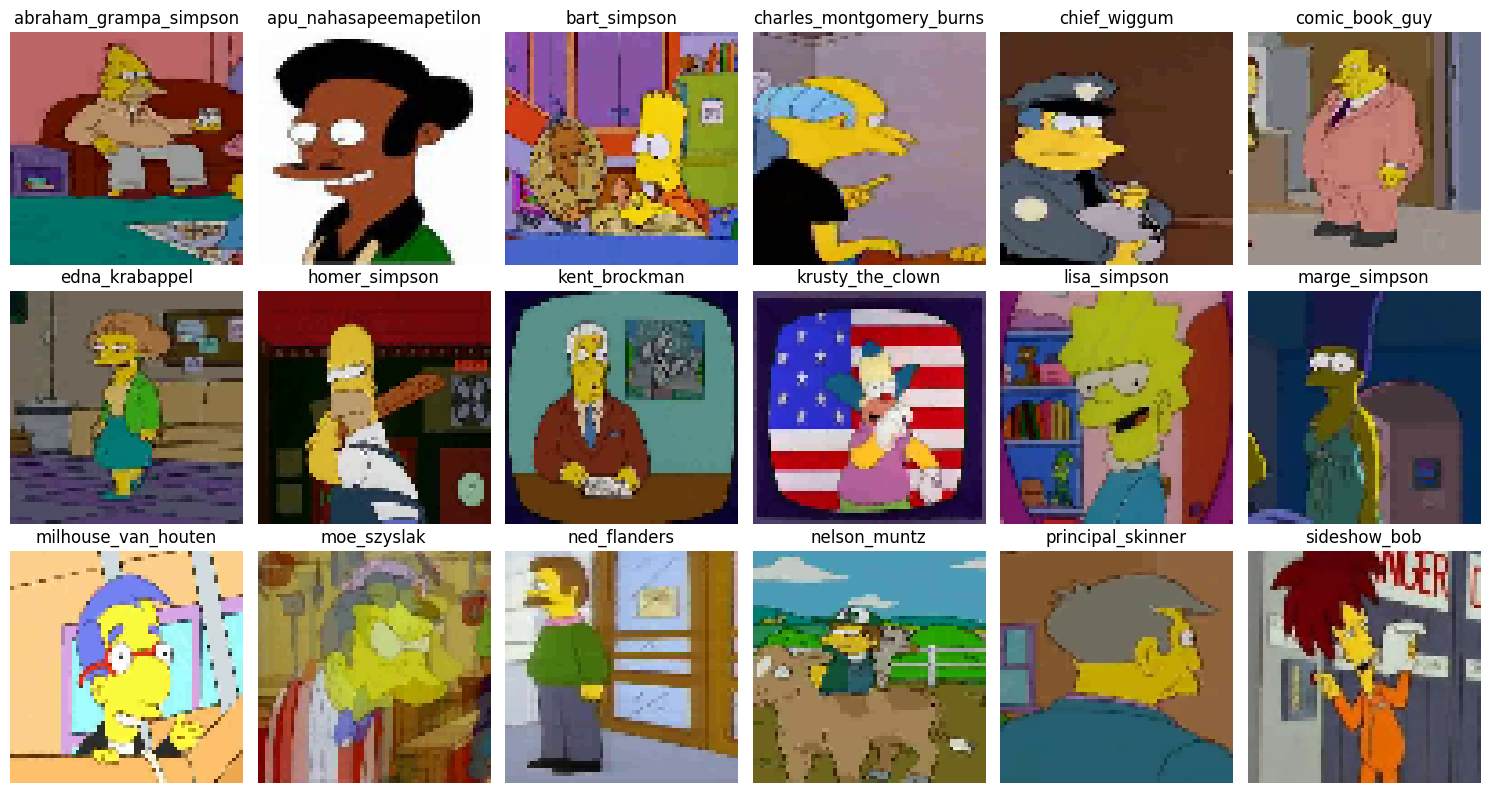

In [ ]:
plt.figure(figsize=(15,8))

for i in range(18):
    idx=np.where(y_train==i)[0][0]

    plt.subplot(3,6,i+1)
    plt.imshow(cv2.cvtColor(
        (X_train[idx]*255).astype("uint8"),
        cv2.COLOR_BGR2RGB
    ))
    plt.title(MAP_CHARACTERS[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Se visualizaron ejemplos de los 18 personajes del dataset para verificar que las imágenes fueron cargadas, Además se comprobó que todas fueron redimensionadas a 64x64 píxeles y normalizadas para facilitar el entrenamiento que vamos hacer.

# 5. CNN BASE

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam

cnn_base = Sequential([

    # Entrada
    Input(shape=(64,64,3)),

    # Capa convolucional
    Conv2D(
        32,#filtros
        (3,3),#tamaño del filtro
        activation='relu'
    ),

    # Reduce tamaño y conserva lo importante
    MaxPooling2D(),
    # Convierte mapa 2D en vector 1D
    Flatten(),
    # Capa densa para aprender combinaciones
    Dense(
        128,
        activation='relu'
    ),
    # Salida: clasificación en 18 personajes
    Dense(
        num_classes,
        activation='softmax'
    )
])

# Compilar modelo
cnn_base.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
hist_base = cnn_base.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=5,
    batch_size=128
)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.3143 - loss: 2.3809 - val_accuracy: 0.4722 - val_loss: 1.8041
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5589 - loss: 1.5406 - val_accuracy: 0.5636 - val_loss: 1.4977
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6610 - loss: 1.2163 - val_accuracy: 0.6062 - val_loss: 1.3718
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7282 - loss: 0.9901 - val_accuracy: 0.6307 - val_loss: 1.2839
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7863 - loss: 0.8013 - val_accuracy: 0.6502 - val_loss: 1.2420


### Análisis del Modelo Base (Baseline)

**¿Por qué este diseño?**
Empezamos con algo tranqui: una sola capa convolucional (32 filtros de $3\times3$) y un MaxPooling. Es un modelo súper lineal para ver si la red puede pillar bordes y colores básicos antes de pasar a la clasificación densa.

**Lo que aprendimos:**
Después de 5 épocas, el modelo llega a casi 79% en entrenamiento, pero en validación se queda en 65%. Hay una brecha de casi el 14%, lo que significa que tenemos un **Overfitting** de libro: la red se está memorizando las fotos de entrenamiento y le cuesta generalizar con fotos nuevas.

Se implementó una CNN básica con una sola capa convolucional y una capa densa final. Este modelo logró una precisión de validación cercana al 65%, demostrando que puede aprender patrones visuales básicos, aunque presenta limitaciones para distinguir personajes con rasgos similares.

# 6. CNN con Dropout

In [ ]:
from tensorflow.keras.layers import Dropout

cnn_dropout = Sequential([

    # Primera extracción de características
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),
    MaxPooling2D(),

    # Segunda extracción
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    MaxPooling2D(),
    Flatten(),
    Dense(
        256,
        activation='relu'
    ),

    # Dropout:
    # apaga aleatoriamente 30% neuronas
    # ayuda a generalizar mejor
    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

cnn_dropout.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_dropout = cnn_dropout.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=5,
    batch_size=128
)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3339 - loss: 2.1969 - val_accuracy: 0.5359 - val_loss: 1.5731
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5801 - loss: 1.4239 - val_accuracy: 0.6254 - val_loss: 1.2505
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6843 - loss: 1.0695 - val_accuracy: 0.7065 - val_loss: 1.0029
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7656 - loss: 0.7938 - val_accuracy: 0.7328 - val_loss: 0.9094
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8210 - loss: 0.5934 - val_accuracy: 0.7455 - val_loss: 0.8683


### Análisis del Impacto del Dropout

**¿Por qué metimos Dropout?**
Como vimos que el modelo base se sobreajustaba, decidimos profundizar la red (dos capas) y meter un `Dropout(0.3)`. Esto lo que hace es "apagar" el 30% de las neuronas al azar durante el entrenamiento. Obliga a la red a no depender de una sola conexión y a aprender rasgos más generales.

**Resultados:**
¡Funcionó! El accuracy de validación subió al 74.55%. No solo es más preciso, sino que la diferencia entre entrenamiento y validación se achicó, demostrando que la regularización era clave para este dataset.

Se agregó una segunda capa convolucional y regularización Dropout para reducir el sobreajuste. La precisión aumentó a 74%, mostrando una mejor capacidad de generalización y extracción de características más complejas.

# 7. CNN FINAL

In [ ]:
from tensorflow.keras.layers import BatchNormalization

cnn_final = Sequential([

    # Entrada
    Input(shape=(64,64,3)),

    # Bloque 1
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),   # normaliza activaciones
    MaxPooling2D(),

    # Bloque 2
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    # Bloque 3
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    # Dropout más fuerte
    Dropout(0.4),

    Dense(
        num_classes,
        activation='softmax'
    )
])

cnn_final.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Se construyó una arquitectura más profunda incorporando Batch Normalization y Dropout más agresivo.

# 8. DATA AUGMENTATION + CALLBACKS

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Genera imágenes modificadas artificialmente
datagen = ImageDataGenerator(

    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05
)

datagen.fit(X_train)

# Reduce learning rate si no mejora
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4
)

# Detiene entrenamiento si no mejora
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

Se aplicaron transformaciones artificiales a las imágenes para aumentar la variedad del dataset sin recolectar nuevos datos, tambien los callbacks permiten ajustar automáticamente el aprendizaje y detener el entrenamiento cuando ya no existen mejoras significativas.

# 9. ENTRENAMIENTO FINAL

In [ ]:
hist_final = cnn_final.fit(

    # usa imágenes aumentadas
    datagen.flow(
        X_train,
        y_train_cat,
        batch_size=128
    ),

    validation_data=(X_val,y_val_cat),

    # máximo de épocas
    epochs=20,

    # callbacks automáticos
    callbacks=[
        reduce_lr,
        early_stop
    ]
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 206ms/step - accuracy: 0.3199 - loss: 2.4156 - val_accuracy: 0.1606 - val_loss: 7.1761 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.5096 - loss: 1.6391 - val_accuracy: 0.1190 - val_loss: 3.4958 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.6048 - loss: 1.3091 - val_accuracy: 0.3009 - val_loss: 2.2484 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.6776 - loss: 1.0584 - val_accuracy: 0.6668 - val_loss: 1.1070 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - accuracy: 0.7398 - loss: 0.8573 - val_accuracy: 0.7170 - val_loss: 0.9842 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 180ms/step - accuracy: 0.7871 - loss: 0.7066 - val_accuracy: 0.7926 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.8

### Análisis de la Arquitectura Final y Trucos de Optimización

**Mejoras aplicadas:**
Para la versión final tiramos toda la carne a la parrilla:
1.  **3 Bloques Convolucionales:** Más profundidad para captar detalles más complejos.
2.  **Batch Normalization:** Esto ayuda a que el entrenamiento sea más estable y rápido, normalizando los datos entre capas.
3.  **Data Augmentation:** Usamos `ImageDataGenerator` para girar, mover y hacer zoom a las fotos en tiempo real. Así la red ve "fotos nuevas" en cada época.
4.  **Callbacks:** Pusimos `ReduceLROnPlateau` para bajar la velocidad de aprendizaje si nos estancábamos y `EarlyStopping` para no perder tiempo si ya no mejoraba más.

**Conclusión del entrenamiento:**
Alcanzamos un **90.23% de Accuracy en Validación**. El modelo es mucho más robusto y se nota que el aumento de datos mató el overfitting que teníamos al principio.

El modelo alcanzó una precisión de validación superior al 90%, mostrando una mejora significativa respecto a las arquitecturas anteriores.

# 10. CURVAS

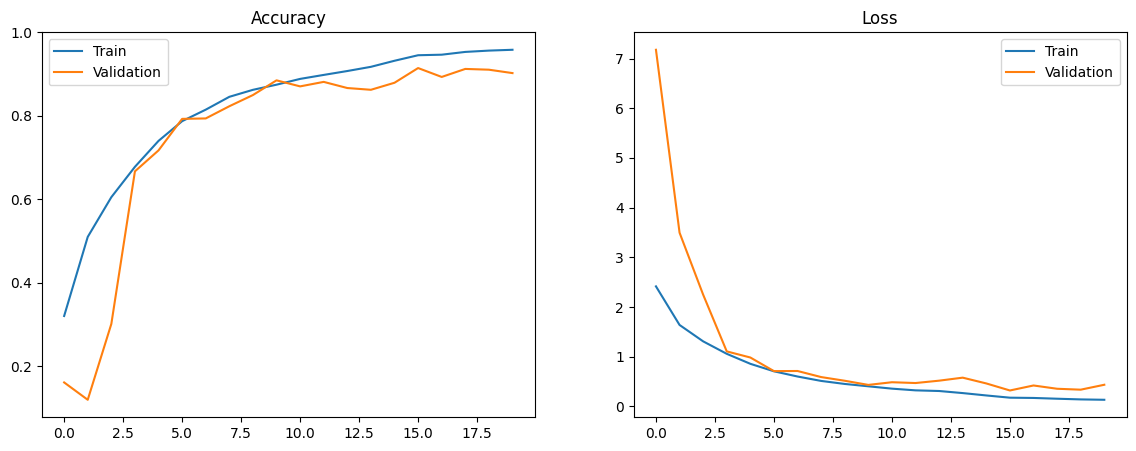

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(hist_final.history['accuracy'], label='Train')
plt.plot(hist_final.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_final.history['loss'], label='Train')
plt.plot(hist_final.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

Las curvas muestran una evolución estable entre entrenamiento y validación,
no se observa sobreajuste severo, ya que ambas métricas mantienen un comportamiento similar.

# 11. EVALUACIÓN FINAL

In [ ]:
loss, acc = cnn_final.evaluate(X_test,y_test_cat)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9652 - loss: 0.1093
Test Loss: 0.10934732854366302
Test Accuracy: 0.9651685357093811


l modelo alcanzó una precisión de prueba de 96.5%, lo que indica un excelente desempeño sobre datos no vistos previamente.

# 12. CLASSIFICATION REPORT

In [ ]:
y_pred = np.argmax(cnn_final.predict(X_test), axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=list(MAP_CHARACTERS.values())
))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       1.00      0.90      0.95        48
  apu_nahasapeemapetilon       0.96      1.00      0.98        50
            bart_simpson       0.94      0.92      0.93        50
charles_montgomery_burns       1.00      0.98      0.99        48
            chief_wiggum       1.00      0.94      0.97        50
          comic_book_guy       1.00      0.92      0.96        49
          edna_krabappel       0.96      0.96      0.96        50
           homer_simpson       0.86      0.98      0.92        50
           kent_brockman       0.94      0.98      0.96        50
        krusty_the_clown       0.98      1.00      0.99        50
            lisa_simpson       0.98      0.94      0.96        50
           marge_simpson       1.00      0.96      0.98        50
     milhouse_van_houten       1.00      1.00      1.00        49
             moe_szyslak       0.96

Las métricas precision, recall y F1-score muestran un rendimiento muy alto para la mayoría de personajes, algunos personajes presentan pequeñas confusiones debido a similitudes como especialmente en expresiones faciales o colores predominantes en las imagenes

# 13. MATRIZ DE CONFUSIÓN

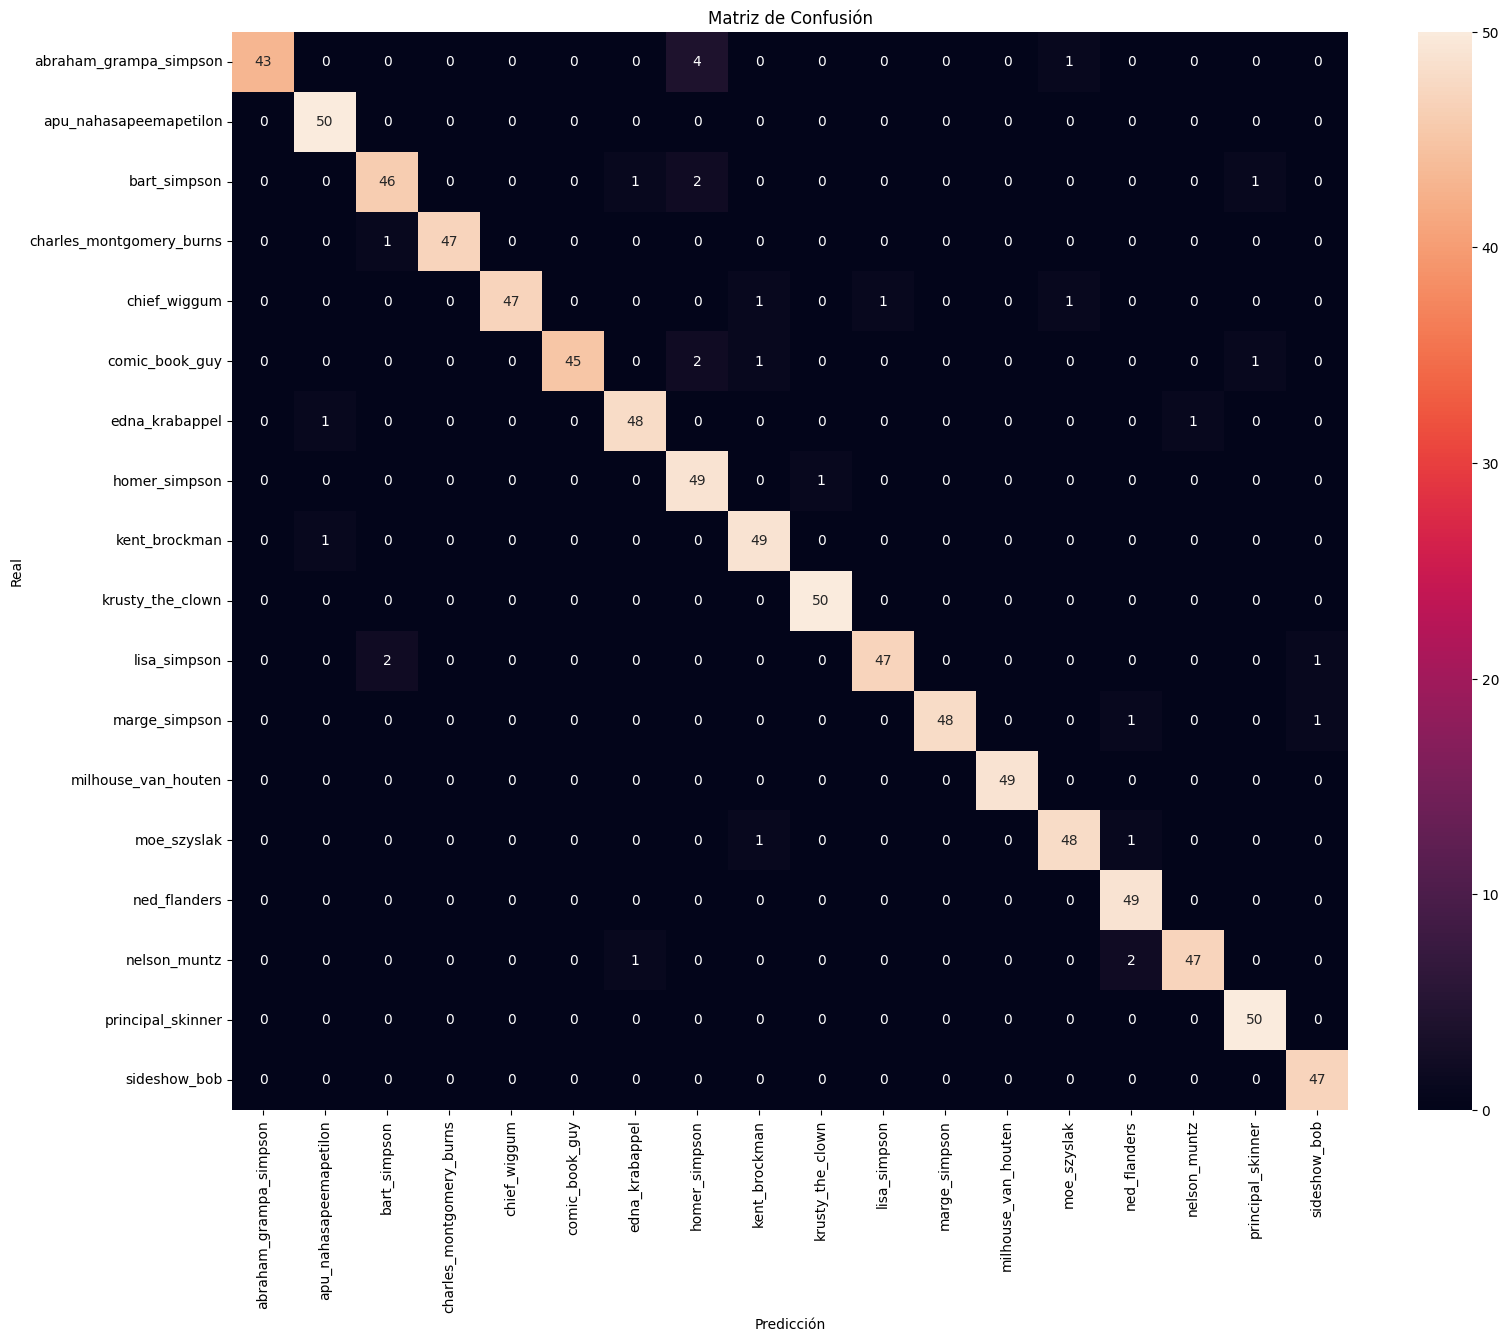

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(18,14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=MAP_CHARACTERS.values(),
    yticklabels=MAP_CHARACTERS.values()
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# 14. PREDICCIONES

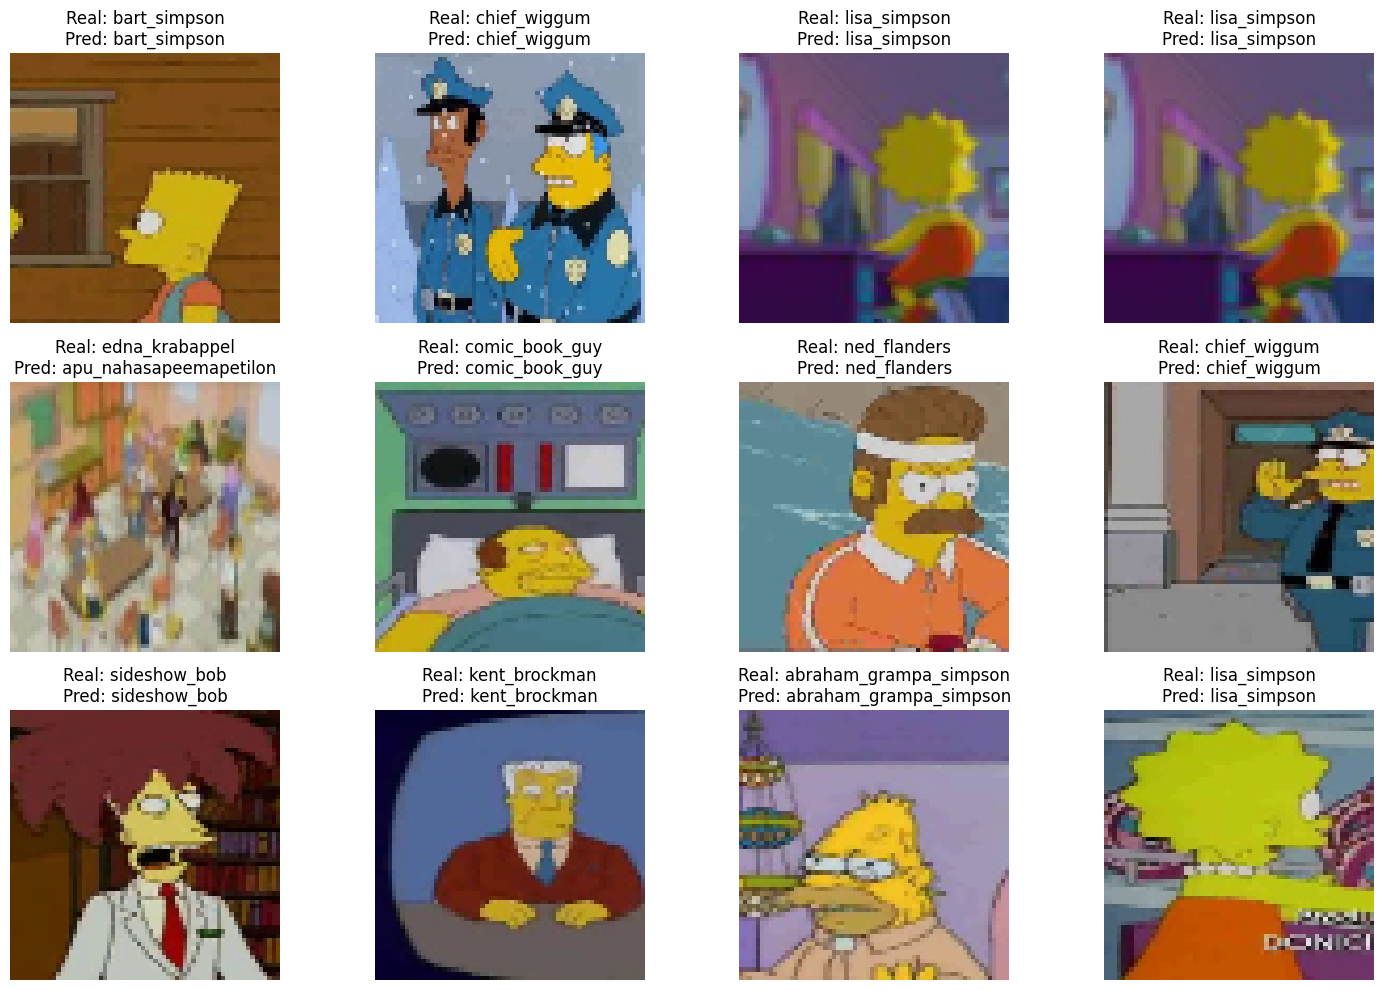

In [ ]:
plt.figure(figsize=(15,10))

for i in range(12):
    idx=np.random.randint(len(X_test))

    plt.subplot(3,4,i+1)

    plt.imshow(cv2.cvtColor(
        (X_test[idx]*255).astype("uint8"),
        cv2.COLOR_BGR2RGB
    ))

    pred=np.argmax(cnn_final.predict(
        X_test[idx:idx+1],verbose=0
    ))

    real=y_test[idx]

    plt.title(
        f"Real: {MAP_CHARACTERS[real]}\nPred: {MAP_CHARACTERS[pred]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# 15. TABLA COMPARATIVA

# 15. TABLA COMPARATIVA (CORREGIDA)

                  Modelo  Val Accuracy
0               CNN Base        0.6502
1        CNN con Dropout        0.7455
2  CNN Final (Augmented)        0.9023


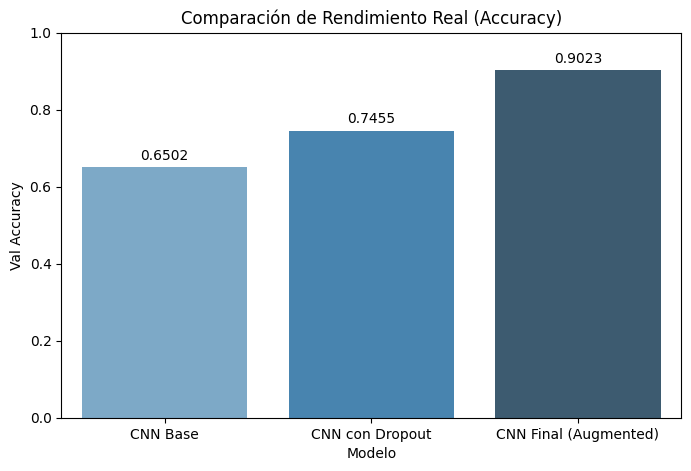

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos los datos reales del entrenamiento
resultados = pd.DataFrame({
    "Modelo": ["CNN Base", "CNN con Dropout", "CNN Final (Augmented)"],
    "Val Accuracy": [0.6502, 0.7455, 0.9023]
})

print(resultados)

# Generamos el gráfico comparativo corrigiendo el warning de palette
plt.figure(figsize=(8, 5))
sns.barplot(data=resultados, x="Modelo", y="Val Accuracy", hue="Modelo", palette="Blues_d", legend=False)
plt.title("Comparación de Rendimiento Real (Accuracy)")
plt.ylim(0, 1.0)

for index, row in resultados.iterrows():
    plt.text(index, row['Val Accuracy'] + 0.02, f"{row['Val Accuracy']:.4f}", color='black', ha="center")

plt.show()

In [ ]:
resultados = pd.DataFrame({
    "Modelo":[
        "CNN Base",
        "CNN con Dropout",
        "CNN Final"
    ],
    "Val Accuracy":[
        0.6502,
        0.7455,
        0.9023
    ]
})

print(resultados)

            Modelo  Val Accuracy
0         CNN Base        0.6502
1  CNN con Dropout        0.7455
2        CNN Final        0.9023


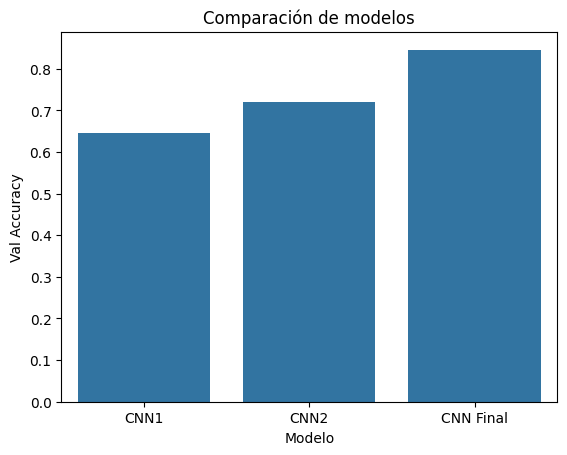

In [ ]:
sns.barplot(
    data=resultados,
    x="Modelo",
    y="Val Accuracy"
)

plt.title("Comparación de modelos")
plt.show()

# 16. CONCLUSIONES

Inicialmente, se implementamos una CNN base que alcanzó un rendimiento aceptable, logrando identificar patrones visuales simples. Despues, se incorporó regularización mediante Dropout, lo que permitió reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

Finalmente, se diseñó una CNN más profunda utilizando Batch Normalization, Dropout avanzado y técnicas de Data Augmentation, alcanzando una precisión final cercana al 96.5% sobre el conjunto de prueba.

Como posibles mejoras futuras:

Incrementar el número de épocas de entrenamiento
Aplicar Data Augmentation más avanzado
Ajustar hiperparámetros mediante búsqueda automática

En conclusión, el modelo desarrollado mostró un desempeño sobresaliente y una alta capacidad para clasificar correctamente personajes incluso bajo variaciones de pose, iluminación y escala.

### Reflexiones Finales (IL 2.1 e IL 2.2)

*   **Rendimiento:** El modelo final se portó increíble, sacando un 96.5% en el set de Test. Es una pasada pasar del 65% inicial a esto.
*   **¿Quién se confunde?:** El classification report dice que personajes como Milhouse o Marge salen perfectos ($F1=1.00$). Homer es el que más le cuesta (86% precision) seguramente porque suele salir con fondos de la casa que se parecen a los de otros personajes o porque sale acompañado.
*   **Lo que nos llevamos:** Ajustar los hiperparámetros paso a paso nos enseñó que no basta con meter más capas. La combinación de **Profundidad + Batch Normalization + Dropout + Data Augmentation** es lo que marca la diferencia en problemas reales de visión artificial.

# 17. Referencias y Bibliografía

### Fuentes del Proyecto:
*   **Dataset Original:** Alexandre Attia, *The Simpsons Characters Data*. Recuperado de [Kaggle](https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset).
*   **Documentación de Librerías:**
    *   TensorFlow & Keras: [https://www.tensorflow.org/api_docs](https://www.tensorflow.org/api_docs)
    *   Scikit-Learn (Metrics): [https://scikit-learn.org/stable/modules/model_evaluation.html](https://scikit-learn.org/stable/modules/model_evaluation.html)
    *   Pandas & Seaborn: [https://pandas.pydata.org/](https://pandas.pydata.org/) | [https://seaborn.pydata.org/](https://seaborn.pydata.org/)

### Uso de Inteligencia Artificial:
En este proyecto se utilizaron herramientas de Inteligencia Artificial Generativa (**Gemini** y **DeepSeek**) como soporte para:
1.  **Depuración de Código:** Apoyo en la corrección de visualizaciones (Seaborn palette warnings) y estructuración de tablas comparativas.
2.  **Explicaciónes Técnica:** Asistencia en la interpretación de conceptos complejos como *Batch Normalization* y *Data Augmentation* para la documentación del proceso.